In [245]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer,PowerTransformer,StandardScaler
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error,mean_squared_error

In [246]:
FILE_PATH = Path.cwd().parent / "datasets" / "winequality-red.csv"

In [247]:
try:
    df = pd.read_csv(FILE_PATH,sep=";") # file is not csv but ssv
except FileNotFoundError :
    print("Unable to find the file path !!!\nPlease enter a valid file path")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
else:
    print(" Dataset loaded successfully")

 Dataset loaded successfully


In [248]:
df.shape

(1599, 12)

In [249]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [250]:
# Initial thoughts : Every NUMERIC column is not on same scale , we would need to use a scaler to normalize these values

In [251]:
df.info() # A really clean dataset and on top of that all numerical values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [252]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [253]:
# Most of the cirtic acid column values are closer to 0 i think as the mean is 0.27 considering the max is 1
# Similar observation for other preceeding cols as well

In [254]:
# We need to plot these into graphs for better evaluation

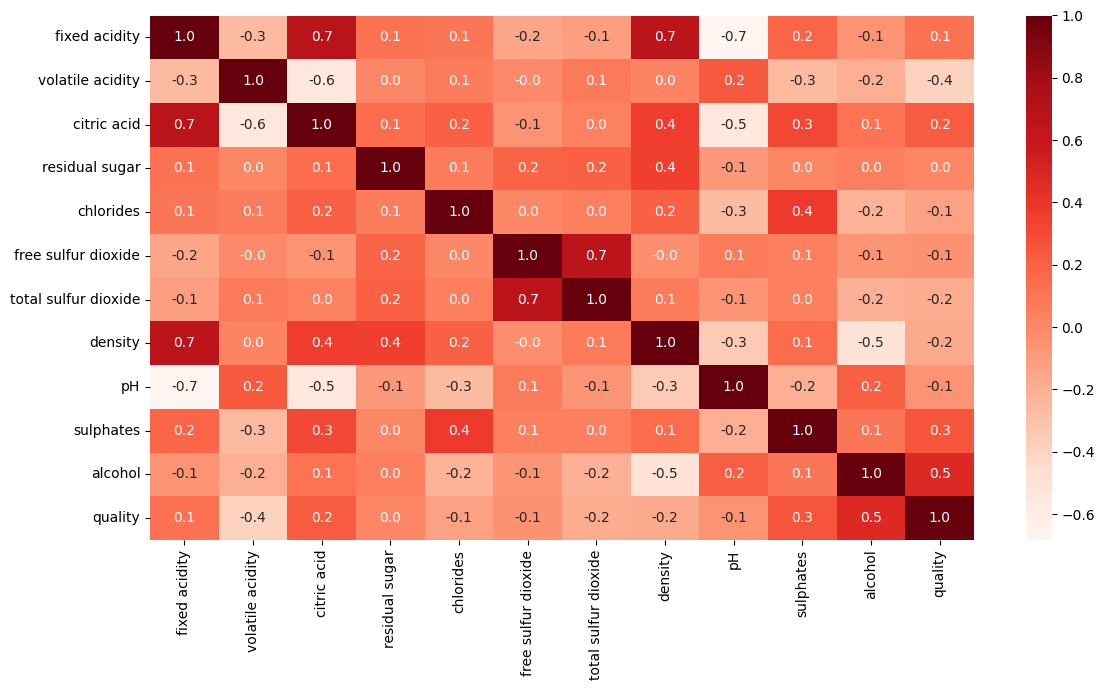

In [255]:
plt.figure(figsize=(12,7))
sns.heatmap(df.corr(),cmap="Reds",annot=True,fmt=".1f")
plt.tight_layout()
plt.show()

In [256]:
# As we clearly see there are some cols of sulfur dioxide and fixed density relating to other cols causing multicollinearity.
# Let's clear this up with doing the VIF test

# VIF for feature :  How much can that feature be predicted using other features 
# The more the value means the more features contribute to that feature 

In [257]:
# 1. Make sure to have a dataset with correlation factors.
df

# 2. Add an intercept column (CRITICAL for accurate VIF metrics)
X = sm.add_constant(df)

# 3. Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# 4. Display results (Excluding the constant row from final evaluation)
print(vif_data[vif_data["Feature"] != 'const'])

                 Feature       VIF
1          fixed acidity  7.772051
2       volatile acidity  1.879663
3            citric acid  3.131055
4         residual sugar  1.703859
5              chlorides  1.500591
6    free sulfur dioxide  1.968010
7   total sulfur dioxide  2.214467
8                density  6.346491
9                     pH  3.339511
10             sulphates  1.487286
11               alcohol  3.238899
12               quality  1.563848


In [258]:
# Looks like we have to deal with fixed acidity as  :
""" 
VIF : fixed acidity > 5 : Warrants attention. Standard errors are slightly inflated.
"""

' \nVIF : fixed acidity > 5 : Warrants attention. Standard errors are slightly inflated.\n'

In [259]:
# What we will first do is drop the density column now and re run the tests above to look for any improvements

In [260]:
df_1 = df.drop(columns=['density'])

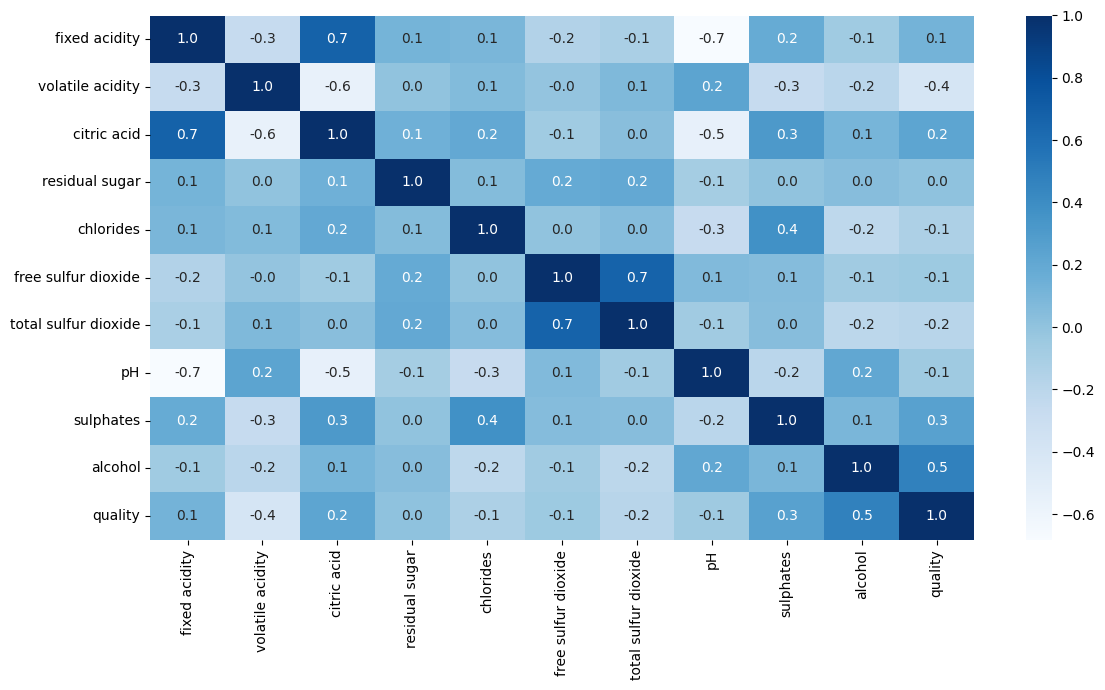

In [261]:
plt.figure(figsize=(12,7))
sns.heatmap(df_1.corr(),cmap="Blues",annot=True,fmt=".1f")
plt.tight_layout()
plt.show()

In [262]:
features = df.drop(columns=['quality'])
X_d = sm.add_constant(features)

# 3. Calculate VIF for each feature
vif_data_1 = pd.DataFrame()
vif_data_1["Feature"] = X_d.columns
vif_data_1["VIF"] = [variance_inflation_factor(X_d.values, i) for i in range(X_d.shape[1])]

# 4. Display results (Excluding the constant row from final evaluation)
print(vif_data_1[vif_data_1["Feature"] != 'const'])

                 Feature       VIF
1          fixed acidity  7.767512
2       volatile acidity  1.789390
3            citric acid  3.128022
4         residual sugar  1.702588
5              chlorides  1.481932
6    free sulfur dioxide  1.963019
7   total sulfur dioxide  2.186813
8                density  6.343760
9                     pH  3.329732
10             sulphates  1.429434
11               alcohol  3.031160


In [263]:
# No fixed acidity  2.975973 < 5 that means we can use this subset for our model prediction

In [264]:
df_raw = df # Save for backup
df = df.drop(columns=['density'])

In [265]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,3.51,0.56,9.4,5


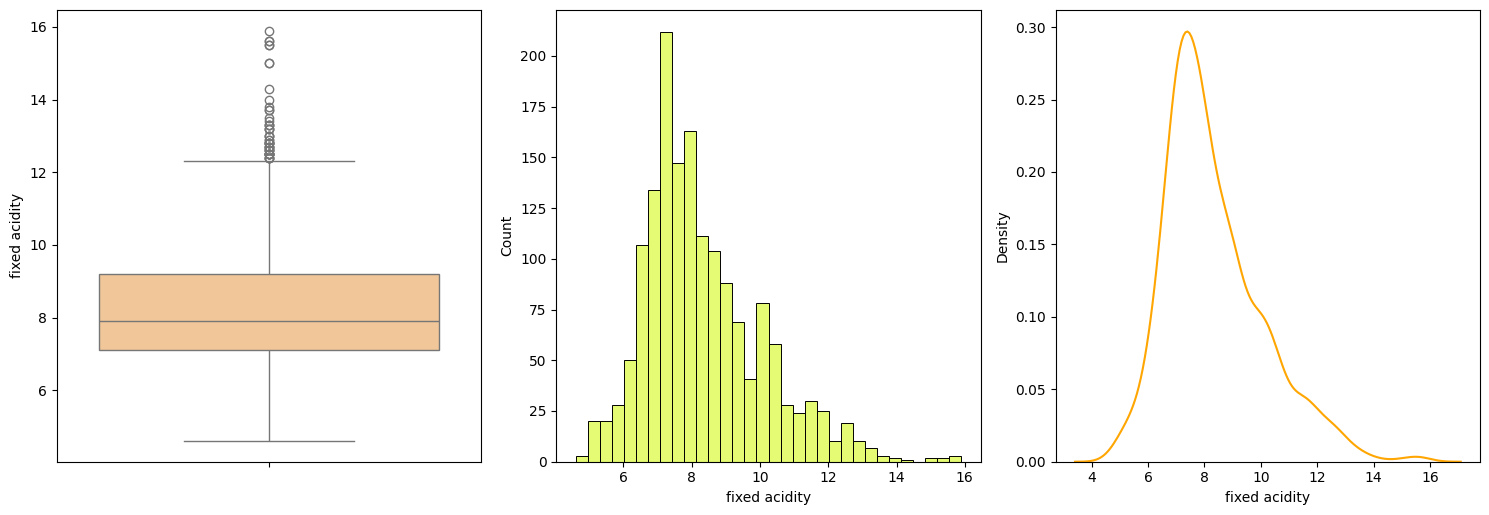

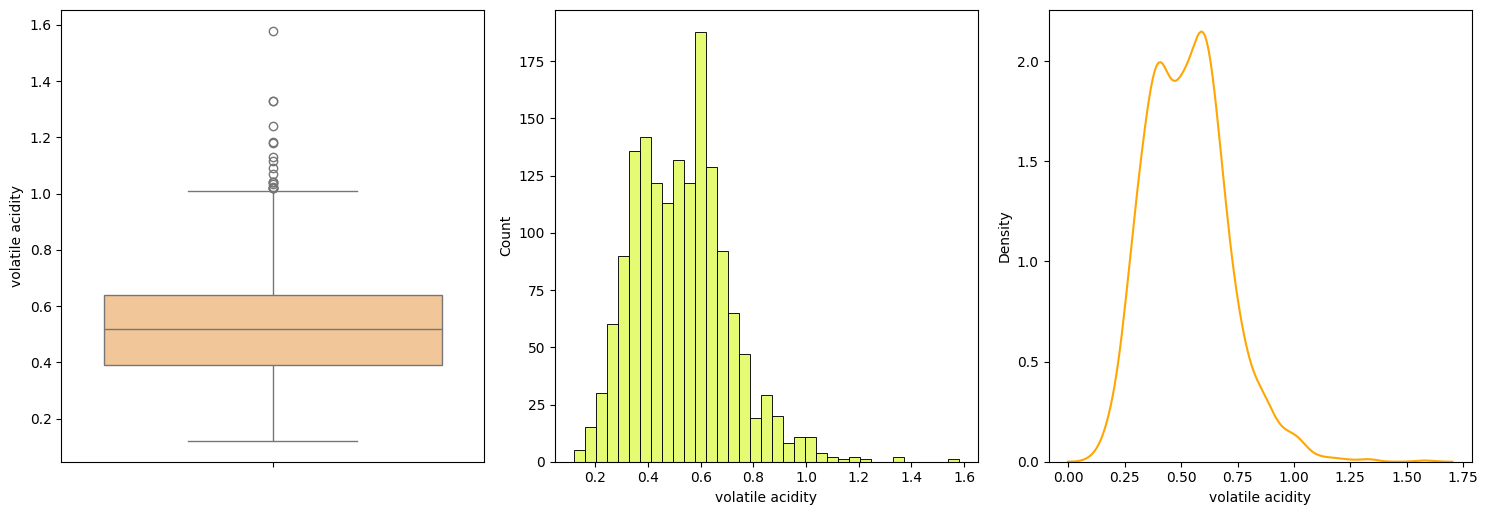

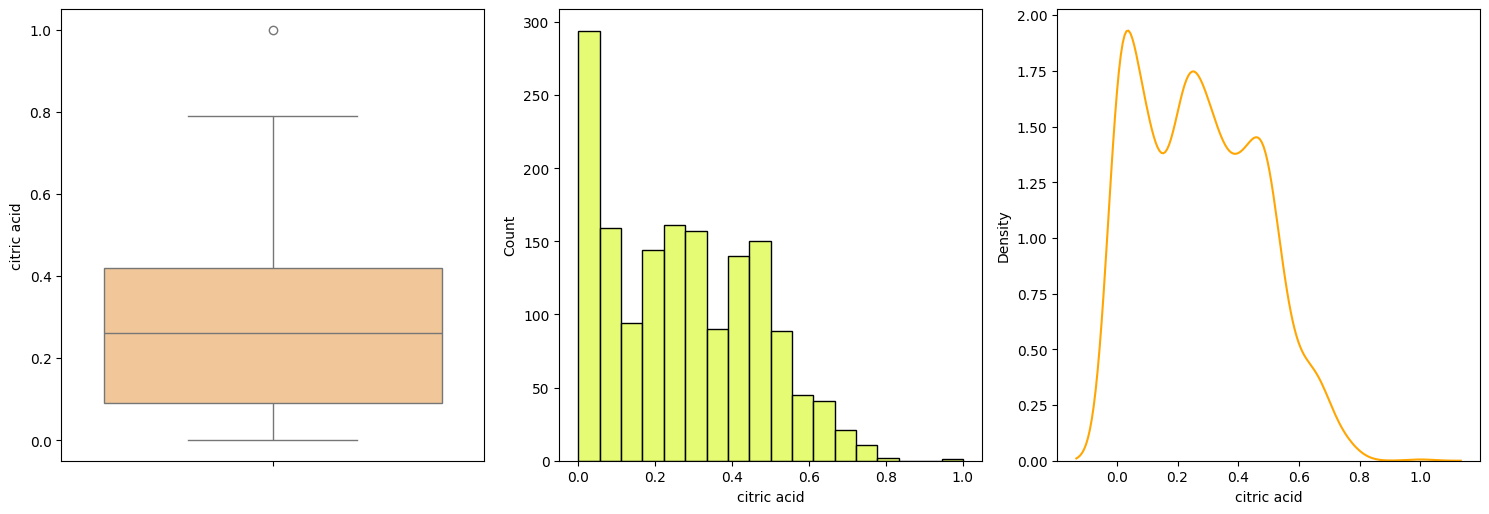

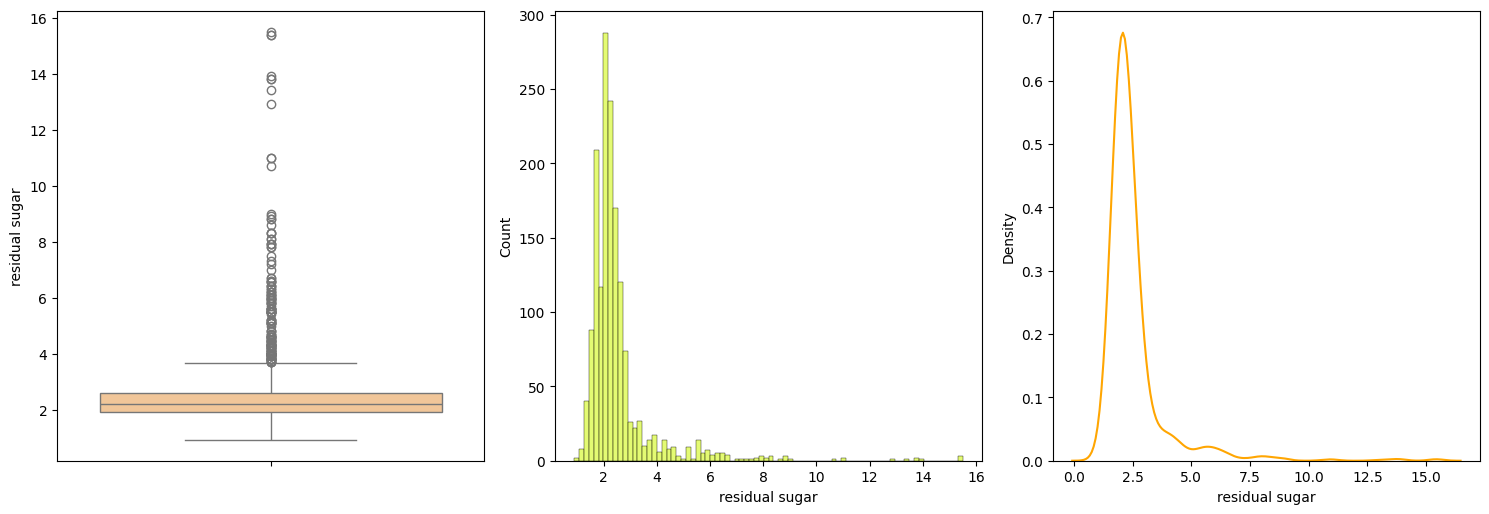

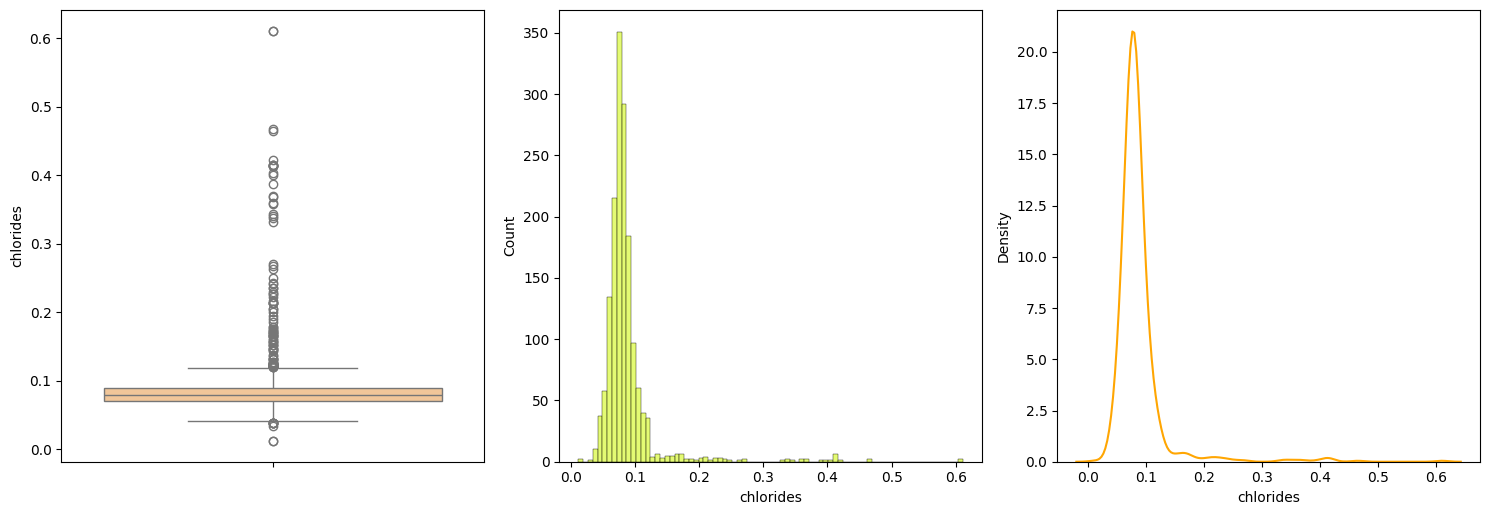

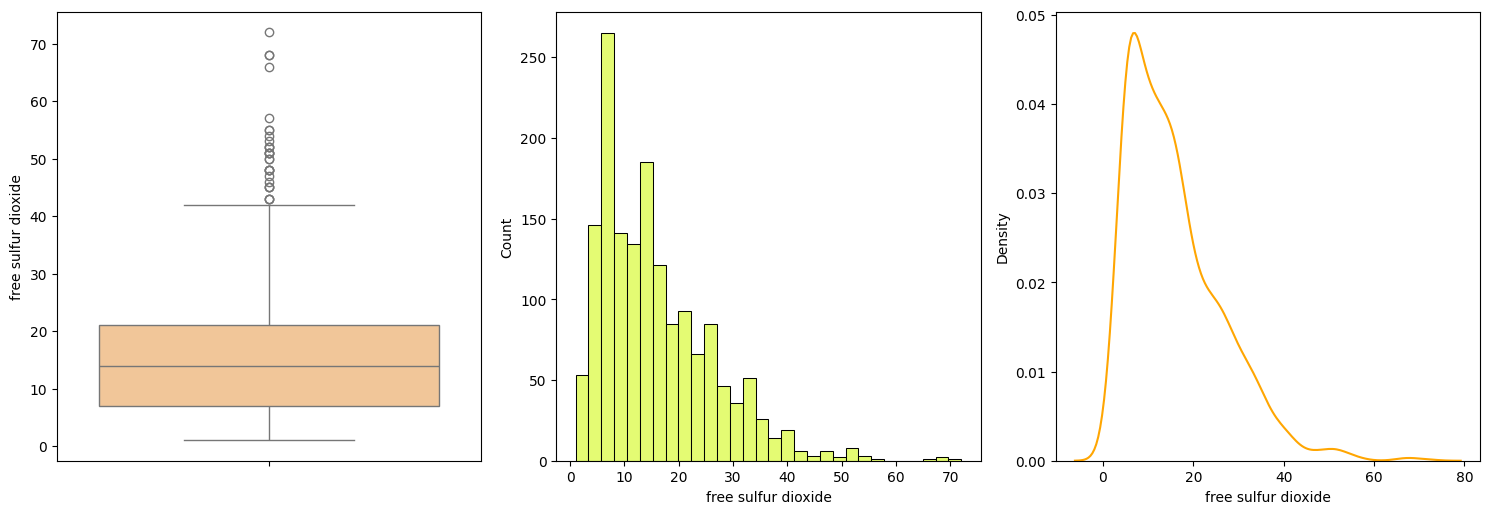

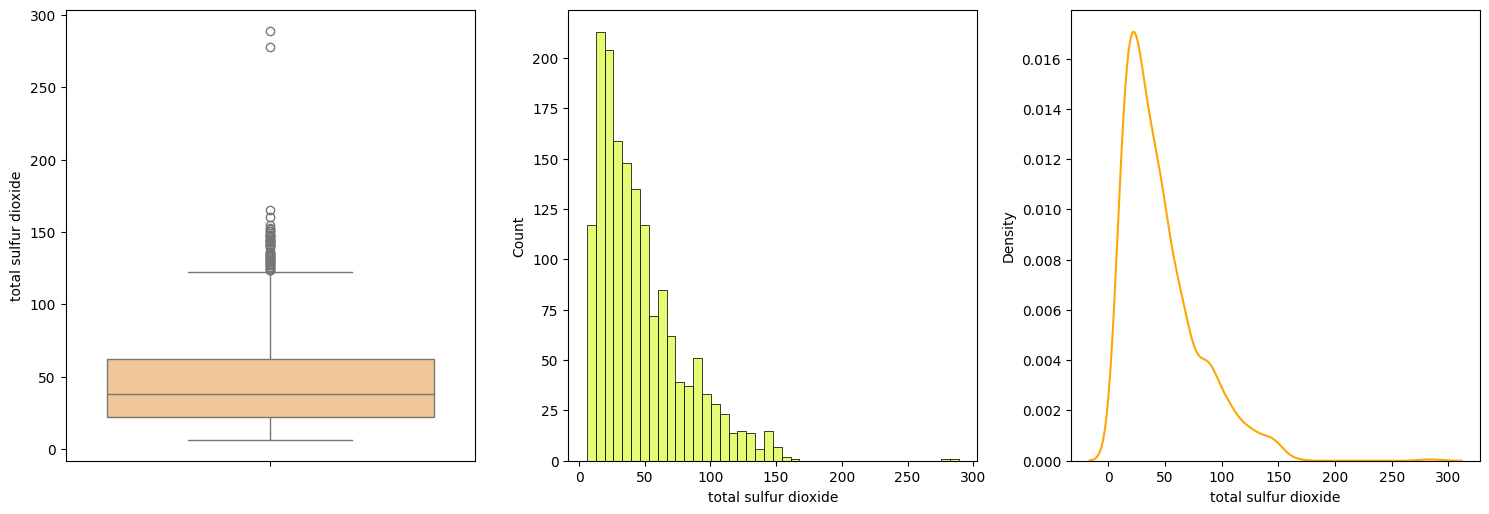

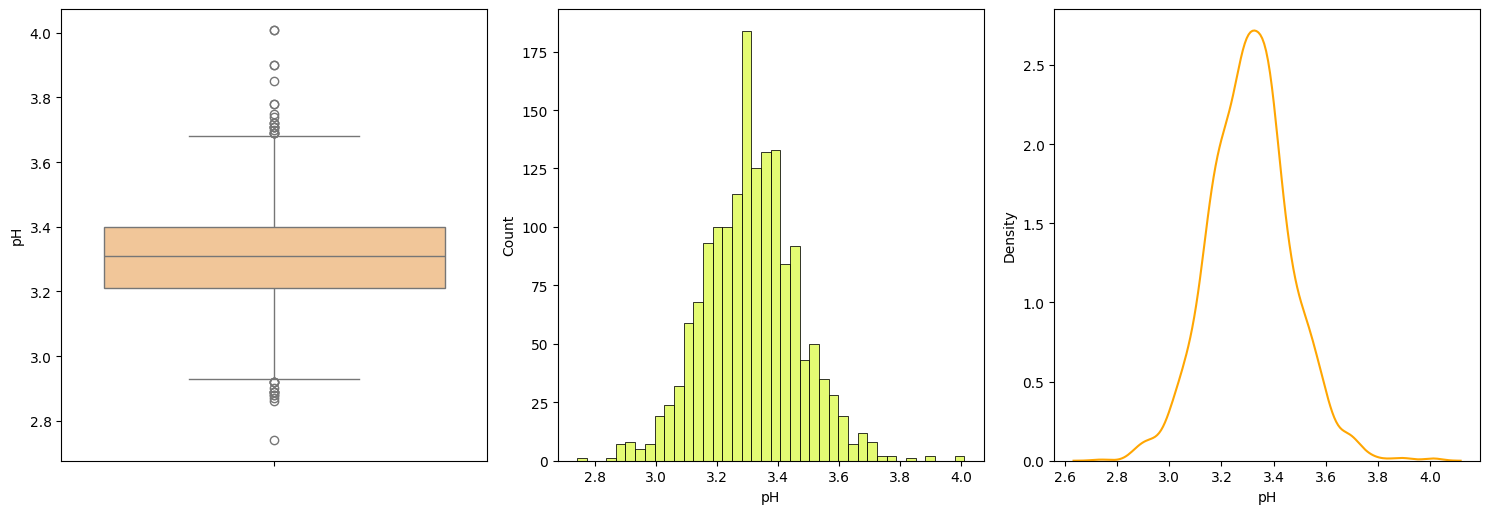

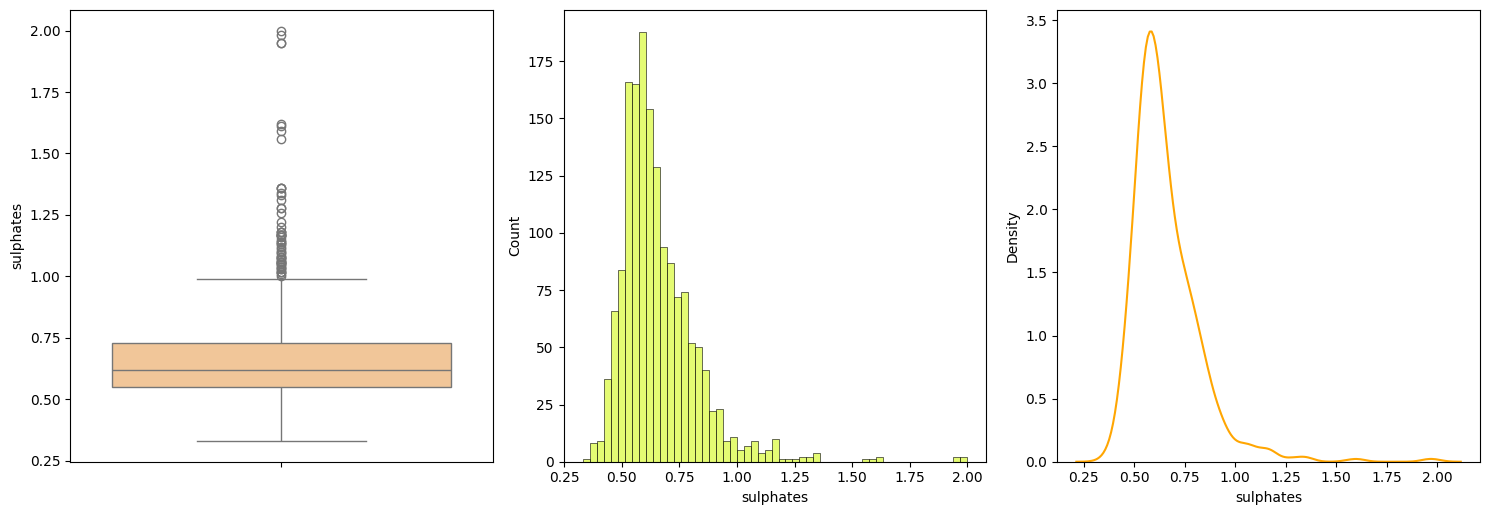

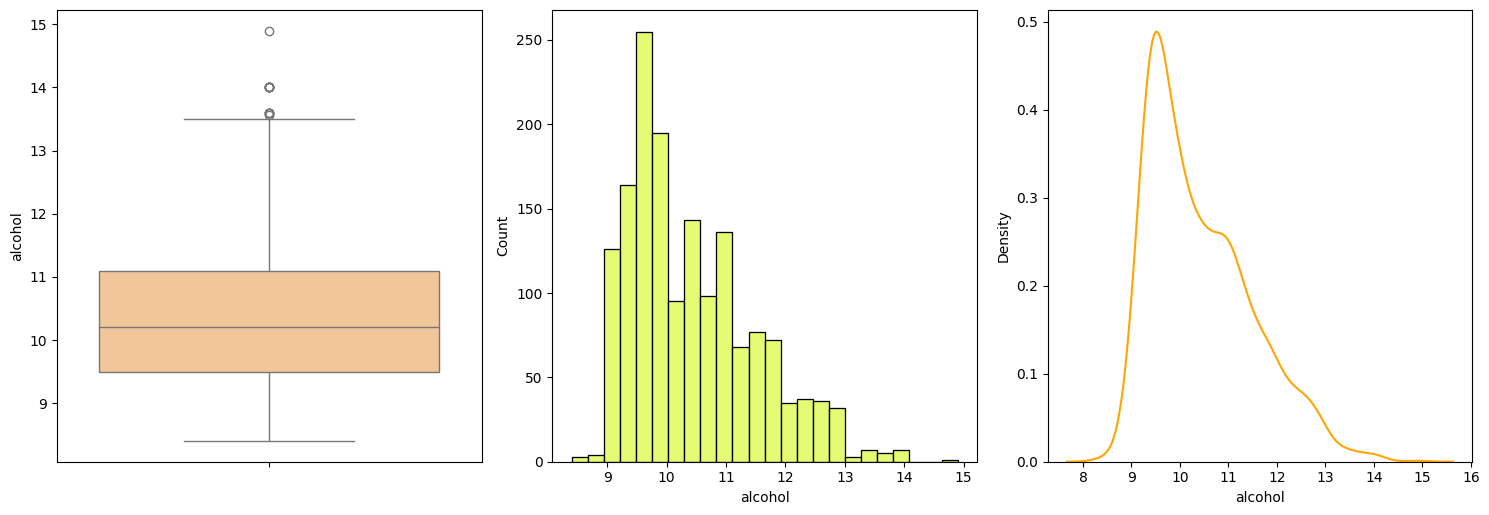

In [266]:
# Let's now try look for the distribution of multiple plots

for x in features.drop(columns=['density']).columns:
    fig , axes = plt.subplots(1,3,figsize=(15,5.25))
    sns.boxplot(data=df[x],ax=axes[0],color="#FFC78B")
    sns.histplot(data=df[x],ax=axes[1],color="#DCFA44")
    sns.kdeplot(data=df[x],ax=axes[2],color="#FFA602")
    plt.tight_layout()
    plt.show()


In [267]:
# Almost completel the columns are right skewed for all the numeric columns
# WE MAY need to devise strategies to deal with these columns
# Especially sulphates , chlorides and residul_sugar groups

In [268]:
# Let's now explore more in deep using IQR analysis

In [269]:
hash = {}
for x in df.drop(columns=['quality']).columns:
    Q1 = df[x].quantile(0.25)
    Q3 = df[x].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5*(IQR)
    upper_limit = Q3 + 1.5*(IQR)
    
    n_rows = len(df[(df[x] > upper_limit) | (df[x] < lower_limit)])

    for y in df[(df[x] > upper_limit) | (df[x] < lower_limit)].index:
        if y in hash:
            continue
        hash[y]=1

    print(f"Number of rows beyond upper_limit and below lower_limit : {n_rows}\tPercentage : {(n_rows/len(df))*100:.2f}%\tColumn : {x}")

Number of rows beyond upper_limit and below lower_limit : 49	Percentage : 3.06%	Column : fixed acidity
Number of rows beyond upper_limit and below lower_limit : 19	Percentage : 1.19%	Column : volatile acidity
Number of rows beyond upper_limit and below lower_limit : 1	Percentage : 0.06%	Column : citric acid
Number of rows beyond upper_limit and below lower_limit : 155	Percentage : 9.69%	Column : residual sugar
Number of rows beyond upper_limit and below lower_limit : 112	Percentage : 7.00%	Column : chlorides
Number of rows beyond upper_limit and below lower_limit : 30	Percentage : 1.88%	Column : free sulfur dioxide
Number of rows beyond upper_limit and below lower_limit : 55	Percentage : 3.44%	Column : total sulfur dioxide
Number of rows beyond upper_limit and below lower_limit : 35	Percentage : 2.19%	Column : pH
Number of rows beyond upper_limit and below lower_limit : 59	Percentage : 3.69%	Column : sulphates
Number of rows beyond upper_limit and below lower_limit : 13	Percentage : 0.

In [270]:
len((hash)) # Around 401 distinct rows to drop

401

In [271]:
# Which is around : 
f"{(len((hash))/len(df))*100:.2f}%"

'25.08%'

In [272]:
# So we cant drop these rows together
# We can do  : 
"""
    winsorzation , capping or any other method.
"""

'\n    winsorzation , capping or any other method.\n'

In [273]:
# I am leaving this step for now , cause I think modifying this much amount of data may lead to problems

In [274]:
"""
🧭 What To Do Next (8 Ordered Steps)
Finish outlier analysis — check all columns, then decide: drop, cap (winsorize), or leave
Log-transform skewed columns — residual sugar, chlorides, sulphates are heavily right-skewed
Train/test split — train_test_split(X, y, test_size=0.2, random_state=42)
Scale AFTER splitting — fit scaler only on train, transform both (prevents data leakage)
Train baseline LinearRegression — get R², MAE, RMSE
Check regression assumptions — residuals vs. fitted, QQ plot, homoscedasticity (you already have regression_assumptions.ipynb as a reference!)
Try Ridge + Lasso — this dataset is noisy; regularization will likely improve results
Interpret coefficients — which features actually drive quality?
"""

'\n🧭 What To Do Next (8 Ordered Steps)\nFinish outlier analysis — check all columns, then decide: drop, cap (winsorize), or leave\nLog-transform skewed columns — residual sugar, chlorides, sulphates are heavily right-skewed\nTrain/test split — train_test_split(X, y, test_size=0.2, random_state=42)\nScale AFTER splitting — fit scaler only on train, transform both (prevents data leakage)\nTrain baseline LinearRegression — get R², MAE, RMSE\nCheck regression assumptions — residuals vs. fitted, QQ plot, homoscedasticity (you already have regression_assumptions.ipynb as a reference!)\nTry Ridge + Lasso — this dataset is noisy; regularization will likely improve results\nInterpret coefficients — which features actually drive quality?\n'

In [275]:
# Now let's try solving the skewness in cols : residual sugar, chlorides, sulphates
# First we will apply log transformation on these cols specifically and compare and look what happens

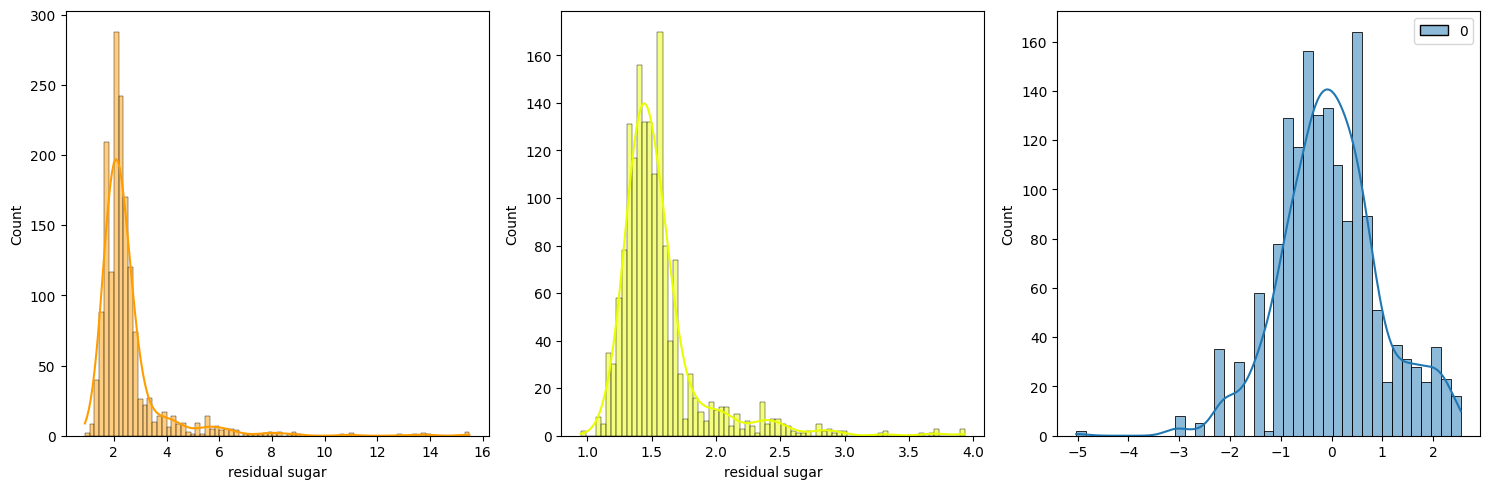

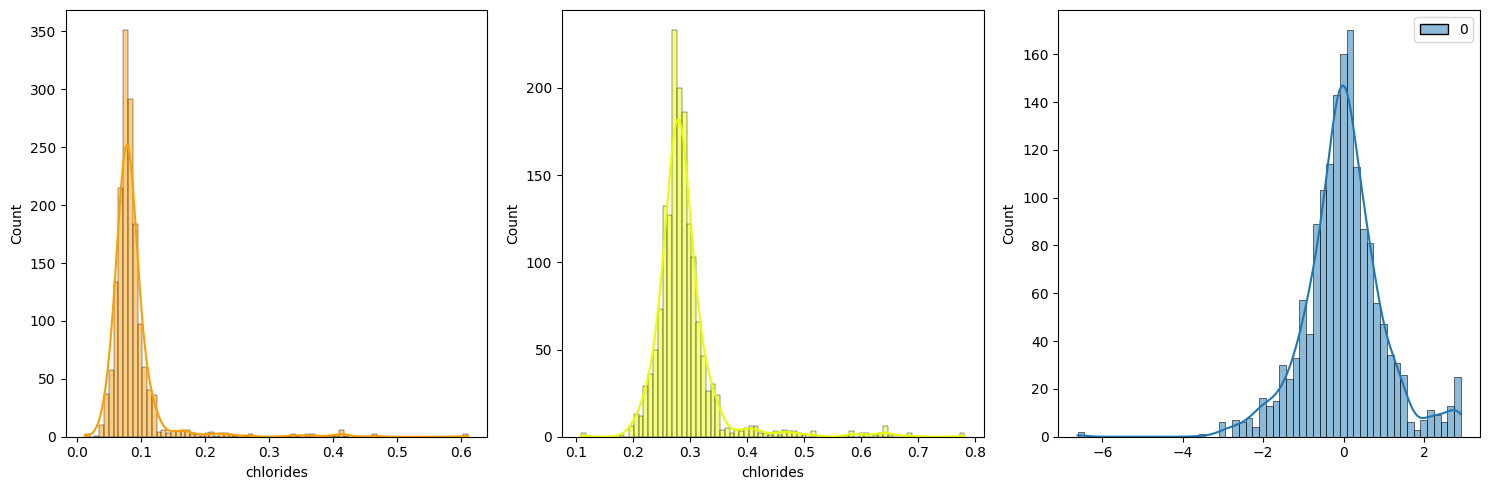

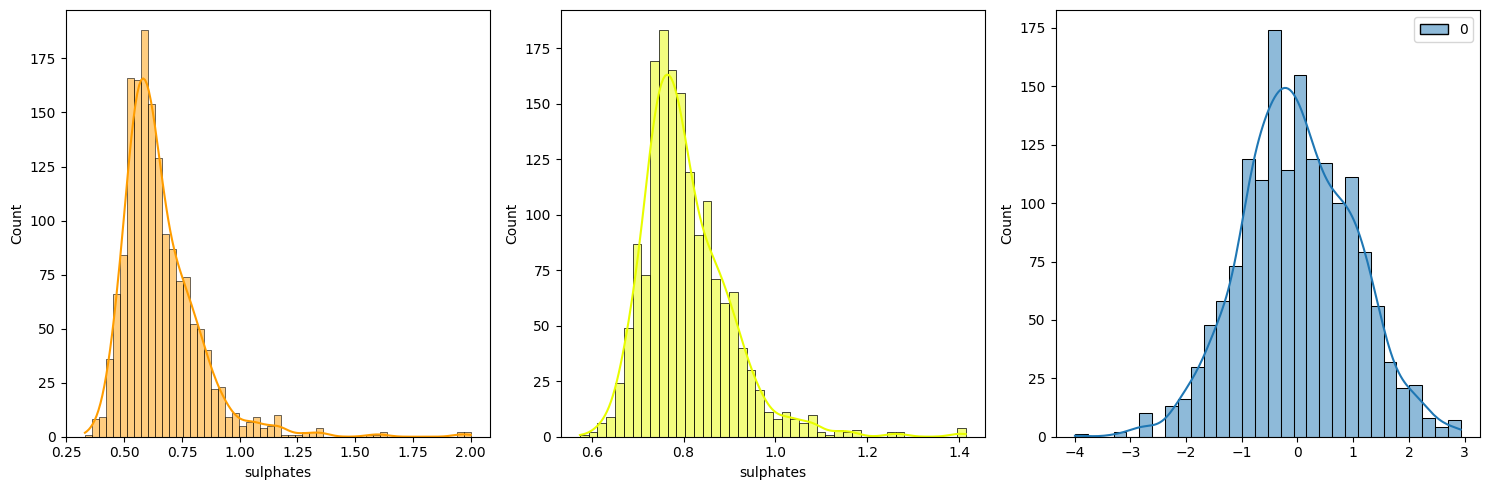

In [276]:
square_root_transformer = FunctionTransformer(func= lambda x : np.sqrt(x))
yeo_johsnon_transformer = PowerTransformer(method="yeo-johnson")

for x in ["residual sugar", "chlorides", "sulphates"]:
    fig , axes = plt.subplots(1,3,figsize=(15,5))
    sns.histplot(data=df[x],ax=axes[0],color="#FF9D00",kde=True)
    sns.histplot(data=square_root_transformer.fit_transform(df[x]),ax=axes[1],color="#E8FD00",kde=True)
    sns.histplot(data=yeo_johsnon_transformer.fit_transform(df[[x]]),ax=axes[2],color="#6AFF00",kde=True)
    plt.tight_layout()
    plt.show()

In [277]:
# Yeo johnson showed the best results so far after sqrt transformer but for some columns it was too strong

In [278]:
# for x in ["residual sugar", "chlorides", "sulphates"]:
#     df[x] = yeo_johsnon_transformer.fit_transform(df[[x]])
# This causesn data leakage so moving this to after splitting

In [279]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,3.51,0.56,9.4,5


In [280]:
# Data splitting
X,y = df.drop(columns=['quality']),df['quality']

In [281]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2)

In [282]:
# Creating a new instant to make sure there is no data leaks
yj = PowerTransformer(method='yeo-johnson',standardize=False)

target_cols = ["residual sugar", "chlorides", "sulphates"]

yj.fit(X_train[target_cols])

X_train[target_cols] = yj.transform(X_train[target_cols])
X_test[target_cols] = yj.transform(X_test[target_cols])

In [283]:
# Necessary for PoissonRegressor and also improves convergence rate
scale = StandardScaler()

scale.fit(X_train)

X_train_scalled = scale.transform(X_train)
X_test_scalled = scale.transform(X_test)

In [284]:
lr_model = LinearRegression()

In [285]:
lr_model.fit(X_train_scalled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [286]:
y_pred = lr_model.predict(X_test_scalled)

In [287]:
print(f"The r2_score of the linear model is : {r2_score(y_test,y_pred):.2f}")
print(f"The mae of the linear model is : {mean_absolute_error(y_test,y_pred):.2f}")
print(f"The mse of the linear model is : {mean_squared_error(y_test,y_pred):.2f}")
print(f"The rmse of the linear model is : {root_mean_squared_error(y_test,y_pred):.2f}")

The r2_score of the linear model is : 0.44
The mae of the linear model is : 0.47
The mse of the linear model is : 0.39
The rmse of the linear model is : 0.62


In [288]:
e = y_test - y_pred

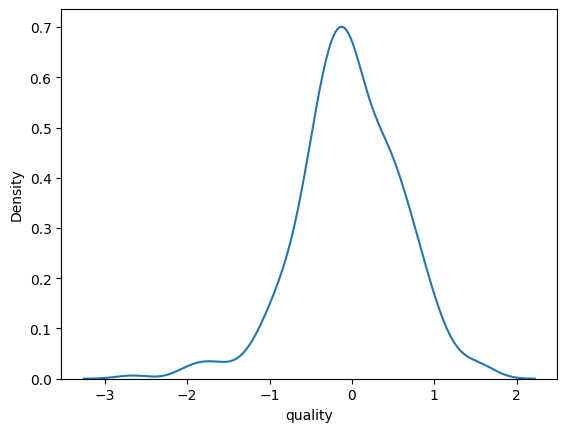

In [289]:
sns.kdeplot(e)
plt.show()
# quite good tbh almost gaussian like curve of residuals

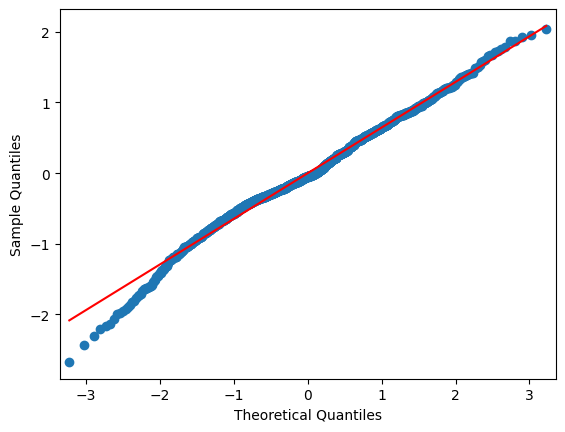

In [290]:
# Now let's plot the qq plot
# First, train your model and get predictions
import statsmodels.api as sm

X_ = sm.add_constant(X) # Statsmodels requires adding a constant for the intercept
model = sm.OLS(y, X_).fit()
residuals = model.resid
fitted_values = model.fittedvalues

from scipy import stats
# 1. Statistical Test (Shapiro-Wilk) - p-value > 0.05 means normally distributed
shapiro_test = stats.shapiro(residuals)

# 2. Visual Check (Q-Q Plot) - Points should follow the straight red line
sm.qqplot(residuals, line='s')
plt.show()

In [291]:
# We can clearly see the right tailedness from the qqplot which we saw earlier in kde plot of residuals

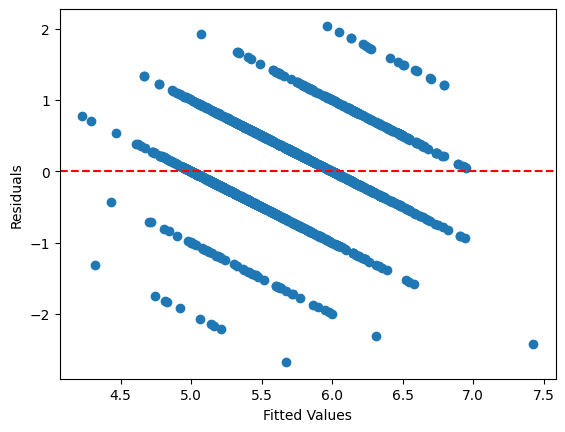

In [292]:
from statsmodels.stats.diagnostic import het_breuschpagan

# 1. Statistical Test - p-value > 0.05 means homoscedastic (good)
bp_test = het_breuschpagan(residuals, model.model.exog)

# 2. Visual Check - Should look like a random cloud, no funnel shape
plt.scatter(fitted_values, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

In [293]:
# We clearly dont see a random cloud of errors ; there is a pattern for these errrors

In [294]:
from statsmodels.stats.stattools import durbin_watson

dw_value = durbin_watson(residuals) # Target value is ~2.0
dw_value

np.float64(1.7547772118084424)

In [295]:
# Using scalled up version + poisson regressor

In [296]:
from sklearn.linear_model import PoissonRegressor

In [297]:
pois_model = PoissonRegressor(max_iter=1000)

In [298]:
pois_model.fit(X_train_scalled,y_train)

,"alpha alpha: float, default=1Constant that multiplies the L2 penalty term and determines theregularization strength. ``alpha = 0`` is equivalent to unpenalizedGLMs. In this case, the design matrix `X` must have full column rank(no collinearities).Values of `alpha` must be in the range `[0.0, inf)`.",1.0
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the linear predictor (`X @ coef + intercept`).",True
,"solver solver: {'lbfgs', 'newton-cholesky'}, default='lbfgs'Algorithm to use in the optimization problem:'lbfgs' Calls scipy's L-BFGS-B optimizer.'newton-cholesky' Uses Newton-Raphson steps (in arbitrary precision arithmetic equivalent to iterated reweighted least squares) with an inner Cholesky based solver. This solver is a good choice for `n_samples` >> `n_features`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features` because it explicitly computes the Hessian matrix. .. versionadded:: 1.2",'lbfgs'
,"max_iter max_iter: int, default=100The maximal number of iterations for the solver.Values must be in the range `[1, inf)`.",1000
,"tol tol: float, default=1e-4Stopping criterion. For the lbfgs solver,the iteration will stop when ``max{|g_j|, j = 1, ..., d} <= tol``where ``g_j`` is the j-th component of the gradient (derivative) ofthe objective function.Values must be in the range `(0.0, inf)`.",0.0001
,"warm_start warm_start: bool, default=FalseIf set to ``True``, reuse the solution of the previous call to ``fit``as initialization for ``coef_`` and ``intercept_`` .",False
,"verbose verbose: int, default=0For the lbfgs solver set verbose to any positive number for verbosity.Values must be in the range `[0, inf)`.",0


In [299]:
y_pred_pois = pois_model.predict(X_test_scalled)

In [300]:
print(f"The r2_score of the poisson model is : {r2_score(y_test,y_pred_pois):.2f}")
print(f"The mae of the poisson model is : {mean_absolute_error(y_test,y_pred_pois):.2f}")
print(f"The mse of the poisson model is : {mean_squared_error(y_test,y_pred_pois):.2f}")
print(f"The rmse of the poisson model is : {root_mean_squared_error(y_test,y_pred_pois):.2f}")

The r2_score of the poisson model is : 0.43
The mae of the poisson model is : 0.48
The mse of the poisson model is : 0.39
The rmse of the poisson model is : 0.63


In [301]:
e_pois = y_test -y_pred_pois

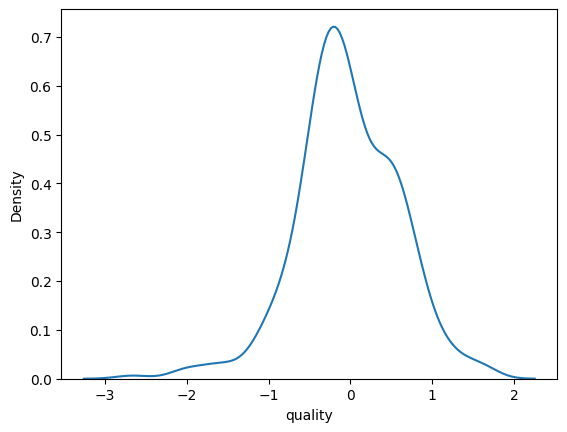

In [302]:
sns.kdeplot(e_pois)
plt.show()

In [303]:
# Performance did not improve drastically - similar to linear model

In [304]:
sgd_model = SGDRegressor(penalty="elasticnet",learning_rate='adaptive')

In [305]:
sgd_model.fit(X_train_scalled,y_train)

,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'elasticnet'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [306]:
y_pred_sgd_ela = sgd_model.predict(X_test_scalled)

In [307]:
print(f"The r2_score of the sgd model is : {r2_score(y_test,y_pred_sgd_ela):.2f}")
print(f"The mae of the sgd model is : {mean_absolute_error(y_test,y_pred_sgd_ela):.2f}")
print(f"The mse of the sgd model is : {mean_squared_error(y_test,y_pred_sgd_ela):.2f}")
print(f"The rmse of the sgd model is : {root_mean_squared_error(y_test,y_pred_sgd_ela):.2f}")

The r2_score of the sgd model is : 0.44
The mae of the sgd model is : 0.47
The mse of the sgd model is : 0.39
The rmse of the sgd model is : 0.62


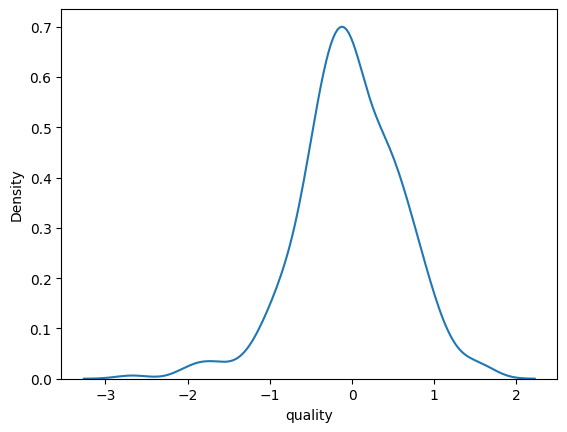

In [308]:
e_sgd = y_test -y_pred_sgd_ela
sns.kdeplot(e_sgd)
plt.show()

In [309]:
# looks like we have a hit a wall that can be reached using the linear models
# Even if we want to improve model performance we cannot as the model cannot because many features dont just contribute that much to the model as we saw earlier.

In [310]:
# Switching to tree based models 

In [311]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

In [312]:
dtr_model = DecisionTreeRegressor(max_depth=6)
dtr_model.fit(X_train_scalled,y_train)
y_pred_dtr = dtr_model.predict(X_test_scalled)

print(f"The r2_score of the DecisionTreeRegressor is : {r2_score(y_test,y_pred_dtr):.2f}")
print(f"The mae of the DecisionTreeRegressor model is : {mean_absolute_error(y_test,y_pred_dtr):.2f}")
print(f"The mse of the DecisionTreeRegressor model is : {mean_squared_error(y_test,y_pred_dtr):.2f}")
print(f"The rmse of the DecisionTreeRegressor model is : {root_mean_squared_error(y_test,y_pred_dtr):.2f}")

The r2_score of the DecisionTreeRegressor is : 0.27
The mae of the DecisionTreeRegressor model is : 0.53
The mse of the DecisionTreeRegressor model is : 0.50
The rmse of the DecisionTreeRegressor model is : 0.71


In [329]:
params = {
    "criterion" : ['squared_error', 'poisson'],
    "max_depth":[5,6,7,8,9]
}

In [330]:
random_search = RandomizedSearchCV(
                                        estimator=DecisionTreeRegressor(),
                                        param_distributions=params,
                                        n_jobs=-1,
                                        n_iter=10,
                                        cv=5,
                                        random_state=42
)

In [331]:
random_search.fit(X_train_scalled,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeRegressor()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['squared_error', 'poisson'], 'max_depth': [5, 6, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold 

In [332]:
# Output the results
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best CV Score: {random_search.best_score_:.4f}")

# Evaluate on the unseen test data
test_accuracy = random_search.score(X_test_scalled, y_test)
print(f"Test Set Accuracy: {test_accuracy:.4f}")

Best Parameters: {'max_depth': 5, 'criterion': 'squared_error'}
Best CV Score: 0.2840
Test Set Accuracy: 0.2896


In [333]:
# There is a limit to Dtr can reach so we call upon random forest now to get better results .

In [334]:
rfr_model = RandomForestRegressor()
rfr_model.fit(X_train_scalled,y_train)
y_pred_rfr = rfr_model.predict(X_test_scalled)

print(f"The r2_score of the RandomForestRegressor is : {r2_score(y_test,y_pred_rfr):.2f}")
print(f"The mae of the RandomForestRegressor model is : {mean_absolute_error(y_test,y_pred_rfr):.2f}")
print(f"The mse of the RandomForestRegressor model is : {mean_squared_error(y_test,y_pred_rfr):.2f}")
print(f"The rmse of the RandomForestRegressor model is : {root_mean_squared_error(y_test,y_pred_rfr):.2f}")

The r2_score of the RandomForestRegressor is : 0.51
The mae of the RandomForestRegressor model is : 0.41
The mse of the RandomForestRegressor model is : 0.34
The rmse of the RandomForestRegressor model is : 0.58


In [335]:
# A drastic change just at first try !!!!
# As expected of the power of 100 DTRs combined